# 06. q-localized policy selection diagnostics

This notebook tests whether the q-localized replay estimator produces a stable and useful policy sequence. The analysis compares localized policy rankings against the full replay ranking, bootstraps days to measure winner stability, and evaluates the policies selected by the localized estimator on the held-out season-three panel.

## What this notebook produces

- A ranking of all non-baseline policies for each localization level `q`.
- A direct comparison between q-localized winners and the full replay winner.
- A day-bootstrap stability analysis for the policy sequence selected by q-localized replay.
- Season-three full-replay and q-localized replay lift for the policies selected on season two.
- Two figures saved to `artifacts/figures/` and rendered inline below.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
        CODE_ROOT = candidate
        break
    if (candidate / "code" / "src").is_dir() and (candidate / "code" / "notebooks").is_dir():
        CODE_ROOT = candidate / "code"
        break
else:
    raise RuntimeError("Could not find the project code root.")

sys.path.insert(0, str(CODE_ROOT / "src"))

from IPython.display import Image, display

from config import ExperimentConfig, ProjectPaths
from paper_experiments import Q_LOCALIZED_VALUES, run_q_localized_policy_selection
from progress import ProgressLogger

paths = ProjectPaths.from_repo_root(CODE_ROOT)
paths.ensure()
config = ExperimentConfig(full_run=True)
progress = ProgressLogger(enabled=True)

print(f"Code root: {CODE_ROOT}")
print(f"q grid: {Q_LOCALIZED_VALUES}")
print(f"Artifacts: {paths.artifact_dir}")

Code root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_support_aware_offline_policy_learning/paper1_support_aware_reserve_policy_selection/code
q grid: [0.01, 0.025, 0.05, 0.1, 0.2]
Artifacts: /home/apex/Documents/ranking_sys/notebooks/writing/ads_support_aware_offline_policy_learning/paper1_support_aware_reserve_policy_selection/code/artifacts


## Run q-localized replay and transfer diagnostics

For each policy and each q, the code identifies the smallest daily bid-threshold radius that captures q of floor-changing observations. It then computes the localized boundary lift using only those observations. The full replay lift remains available as the benchmark ranking.

In [2]:
artifacts = run_q_localized_policy_selection(paths, config, progress)

[18:29:35] >> Running q-localized policy-selection diagnostics.
[18:29:37]    Using cached replay artifacts for 02_season2.
[18:29:37]    Using cached replay artifacts for 04_season3.
[18:29:37]    Computing q-localized replay on ipinyou_season2_20130606.parquet.
[18:30:00]    Computing q-localized replay on ipinyou_season2_20130607.parquet.
[18:30:27]    Computing q-localized replay on ipinyou_season2_20130608.parquet.
[18:30:37]    Computing q-localized replay on ipinyou_season2_20130609.parquet.
[18:31:03]    Computing q-localized replay on ipinyou_season2_20130610.parquet.
[18:31:14]    Computing q-localized replay on ipinyou_season2_20130611.parquet.
[18:31:24]    Computing q-localized replay on ipinyou_season2_20130612.parquet.
[18:31:32]    Computing q-localized replay on ipinyou_season3_20131019.parquet.
[18:31:33]    Computing q-localized replay on ipinyou_season3_20131020.parquet.
[18:31:34]    Computing q-localized replay on ipinyou_season3_20131021.parquet.
[18:31:37]    Co

## Policy sequence across q

The first table shows the top five q-localized policies at each localization level. Stable policy identities across q indicate that the ranking is not driven by one arbitrary boundary-window choice.

In [3]:
display(
    artifacts["top_sequence"][[
        "q",
        "localized_rank",
        "policy_number",
        "policy_label",
        "localized_boundary_lift",
        "localized_total_lift",
        "season2_full_replay_lift",
        "season2_full_replay_rank",
        "mean_localized_radius",
        "localized_count",
    ]].head(25)
)

,q,localized_rank,policy_number,policy_label,localized_boundary_lift,localized_total_lift,season2_full_replay_lift,season2_full_replay_rank,mean_localized_radius,localized_count
0,0.010,1.0,P11,Positive Floors To Q75,0.647012,0.062474,0.355075,2,138.000000,7637018
1,0.010,2.0,P18,Q75 Margin-Gated Floor,0.231031,0.040767,0.476604,1,127.000000,2851753
2,0.010,3.0,P10,Positive Floors To Q50,0.184576,0.016678,0.072978,7,188.000000,7278659
3,0.010,4.0,P16,Gap 100 Add 20,0.084676,0.001321,0.097883,5,122.142857,1063013
4,0.010,5.0,P17,Q50 Margin-Gated Floor,0.052761,0.009310,0.101179,4,177.000000,2851753
18,0.025,1.0,P11,Positive Floors To Q75,0.647012,0.062474,0.355075,2,138.000000,7637018
19,0.025,2.0,P18,Q75 Margin-Gated Floor,0.231031,0.040767,0.476604,1,127.000000,2851753
20,0.025,3.0,P10,Positive Floors To Q50,0.184576,0.016678,0.072978,7,188.000000,7278659
21,0.025,4.0,P16,Gap 100 Add 20,0.109833,0.003583,0.097883,5,133.285714,1641988
22,0.025,5.0,P17,Q50 Margin-Gated Floor,0.052761,0.009310,0.101179,4,177.000000,2851753


## Comparison with full replay

This table asks whether the localized winner agrees with the aggregate full-replay winner. Disagreement is not automatically bad. It means the localized estimator is prioritizing boundary-supported evidence differently from the aggregate replay score.

In [4]:
display(artifacts["comparison"])

,q,q_localized_winner_policy_id,q_localized_winner_policy_number,q_localized_winner_policy_label,q_localized_winner_score,q_localized_winner_full_replay_lift,q_localized_winner_full_replay_rank,matches_full_replay_leader,full_replay_leader_policy_id,full_replay_leader_policy_number,full_replay_leader_policy_label,full_replay_leader_lift
0,0.010,min_positive_floor_q75,P11,Positive Floors To Q75,0.647012,0.355075,2,False,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,0.476604
18,0.025,min_positive_floor_q75,P11,Positive Floors To Q75,0.647012,0.355075,2,False,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,0.476604
36,0.050,min_positive_floor_q75,P11,Positive Floors To Q75,0.662264,0.355075,2,False,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,0.476604
54,0.100,min_positive_floor_q75,P11,Positive Floors To Q75,0.617061,0.355075,2,False,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,0.476604
72,0.200,min_positive_floor_q75,P11,Positive Floors To Q75,0.578742,0.355075,2,False,hybrid_q75_if_gap_100,P18,Q75 Margin-Gated Floor,0.476604


## Resampling stability

The bootstrap resamples days with replacement. For each draw and each q, it recomputes the localized winner. The winner frequency table measures whether the selected sequence is robust to day-level traffic variation.

In [5]:
display(
    artifacts["bootstrap_summary"][[
        "q",
        "selected_policy_number",
        "selected_policy_label",
        "selection_frequency",
        "mean_selected_localized_boundary_lift",
    ]].head(20)
)

,q,selected_policy_number,selected_policy_label,selection_frequency,mean_selected_localized_boundary_lift
0,0.010,P11,Positive Floors To Q75,1.0,0.647224
1,0.025,P11,Positive Floors To Q75,1.0,0.647749
2,0.050,P11,Positive Floors To Q75,1.0,0.663081
3,0.100,P11,Positive Floors To Q75,1.0,0.619294
4,0.200,P11,Positive Floors To Q75,1.0,0.579266


## Season-three transfer of q-localized selections

The final table evaluates the season-two q-localized winners on the held-out season-three panel. The key column is `season3_full_replay_lift`, which reports the out-of-time aggregate replay lift of each policy selected by the localized estimator.

In [6]:
display(
    artifacts["season3_transfer"][[
        "q",
        "policy_number",
        "policy_label",
        "season2_localized_boundary_lift",
        "season2_full_replay_lift",
        "season2_full_replay_rank",
        "season3_full_replay_lift",
        "season3_localized_boundary_lift",
        "season3_localized_rank",
        "season3_retained_impression_share",
    ]]
)

,q,policy_number,policy_label,season2_localized_boundary_lift,season2_full_replay_lift,season2_full_replay_rank,season3_full_replay_lift,season3_localized_boundary_lift,season3_localized_rank,season3_retained_impression_share
0,0.010,P11,Positive Floors To Q75,0.647012,0.355075,2,0.299696,0.734004,2.0,1.0
1,0.025,P11,Positive Floors To Q75,0.647012,0.355075,2,0.299696,0.734004,2.0,1.0
2,0.050,P11,Positive Floors To Q75,0.662264,0.355075,2,0.299696,0.734004,2.0,1.0
3,0.100,P11,Positive Floors To Q75,0.617061,0.355075,2,0.299696,0.734004,2.0,1.0
4,0.200,P11,Positive Floors To Q75,0.578742,0.355075,2,0.299696,0.734004,2.0,1.0


## Figures

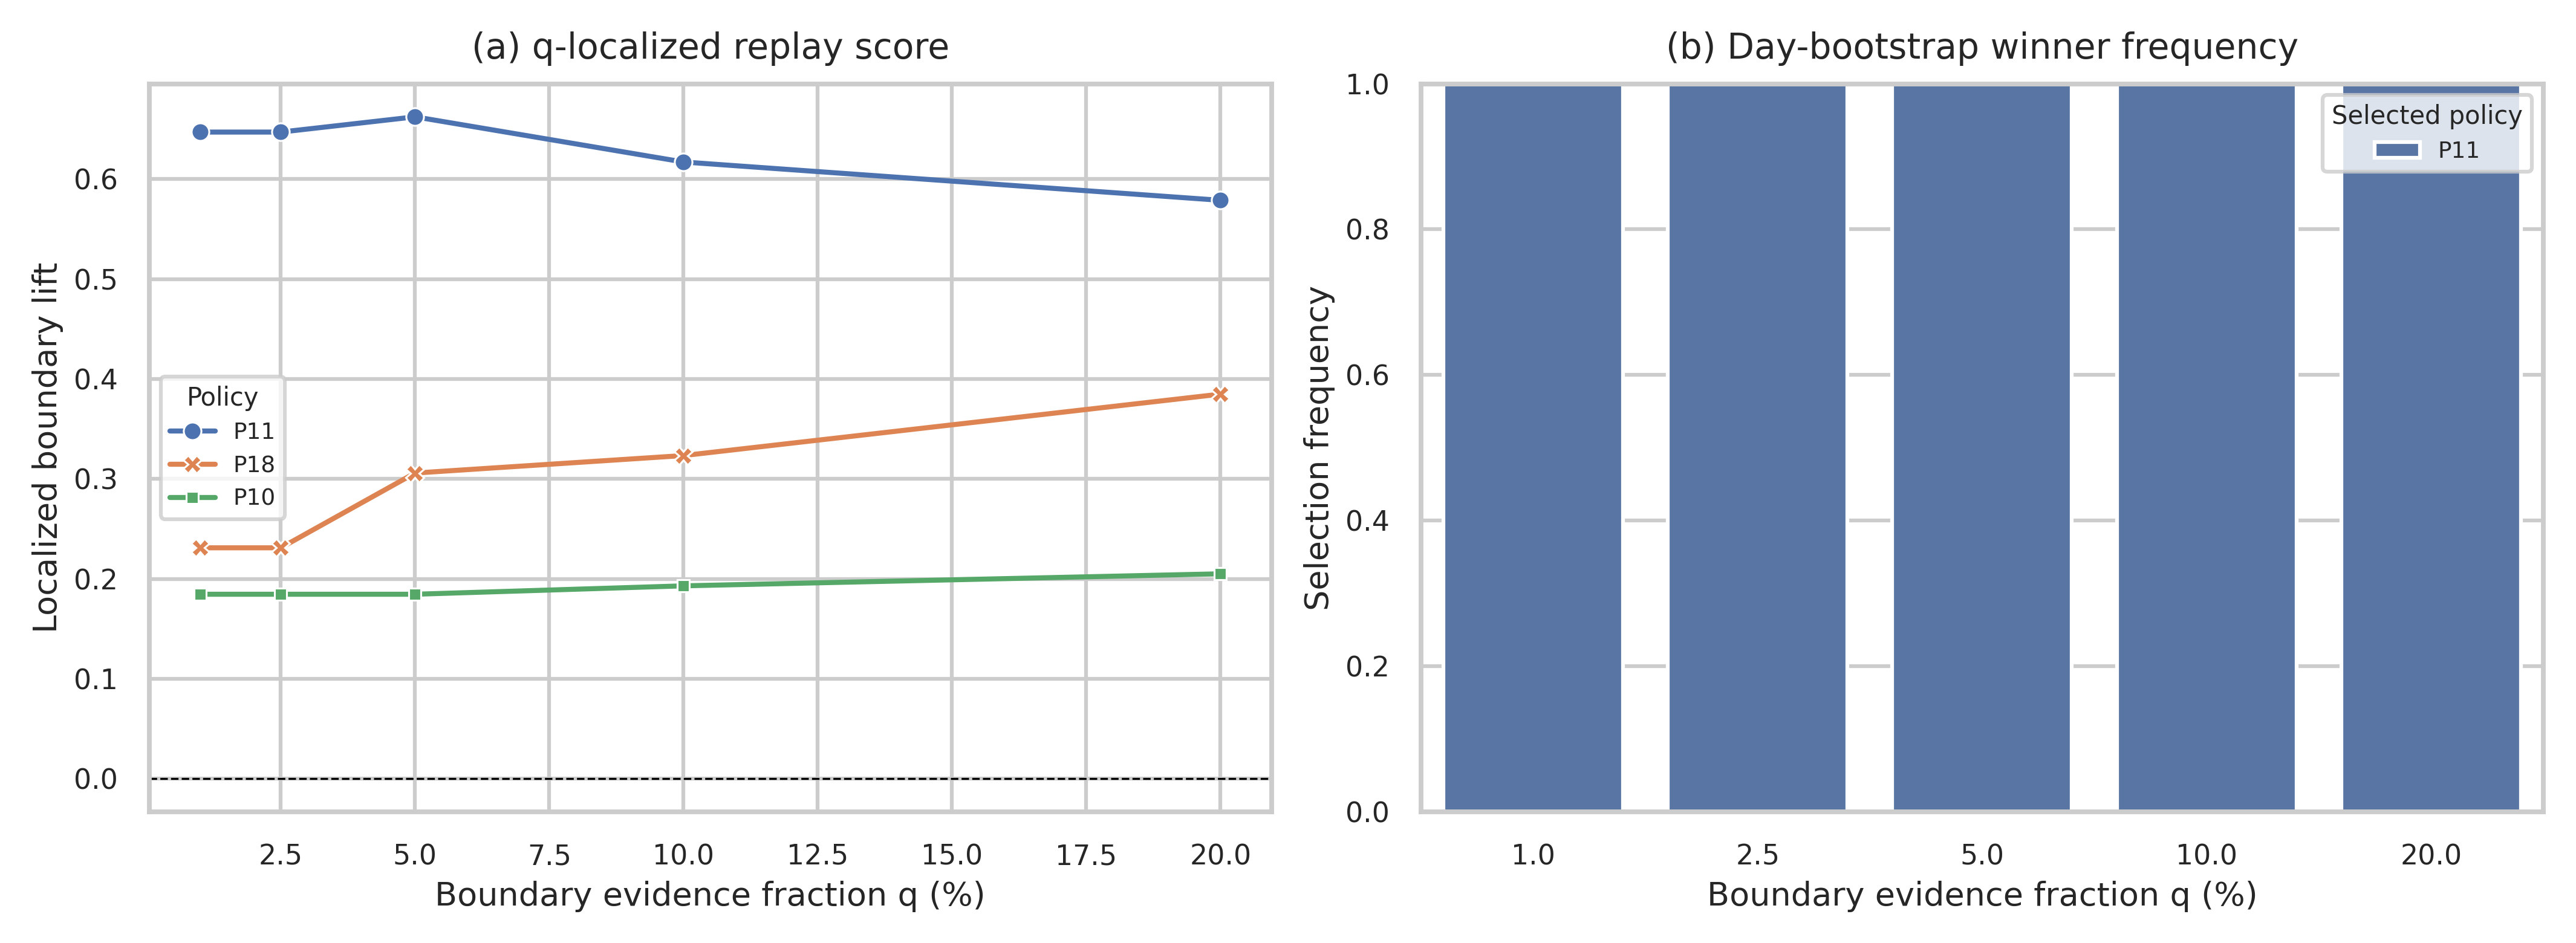

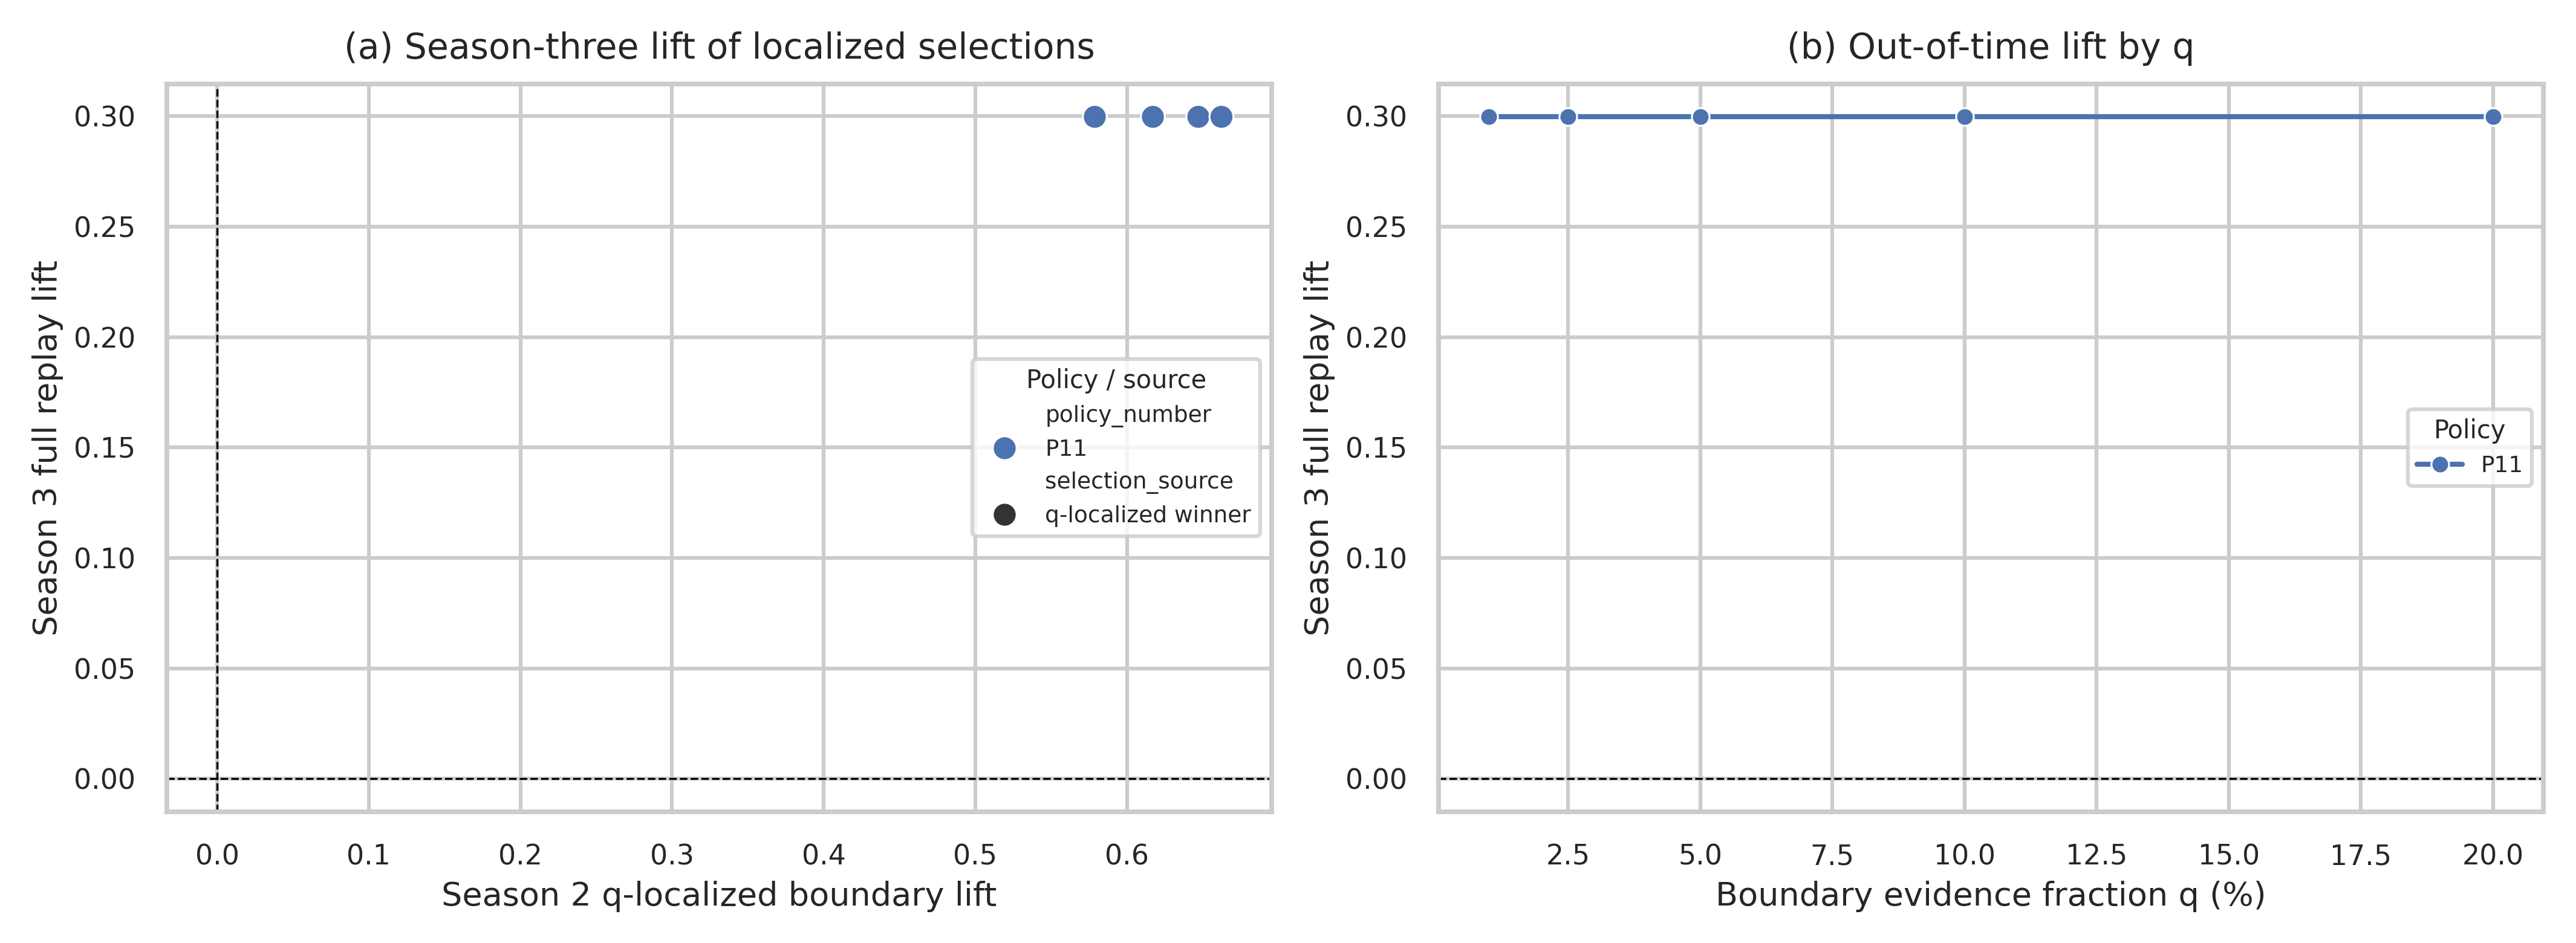

In [7]:
display(Image(filename=str(artifacts["selection_figure"])))
display(Image(filename=str(artifacts["transfer_figure"])))